In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import importlib
import astropy.units as u

import sys
sys.path.append('/global/homes/c/cpopik/CAPPIBARAS')

import Plots
import TargetData
import Models.Studies as Studies

# Plot Styling
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family':'serif', 'mathtext.fontset':'dejavuserif',
    'axes.grid':True, 'grid.linestyle': ':', 'grid.alpha': 0.5,
    'xtick.direction':'in', 'xtick.minor.visible': True, 'xtick.top':True,
    'ytick.direction':'in', 'ytick.minor.visible': True, 'ytick.right':True,
    'figure.figsize': [9, 6], 'axes.titlesize':30, 'legend.fontsize': 15, 'legend.title_fontsize': 20,
    'axes.labelsize':25, 'xtick.labelsize':15, 'ytick.labelsize':15
})

# Checked

## Kusiak 2022

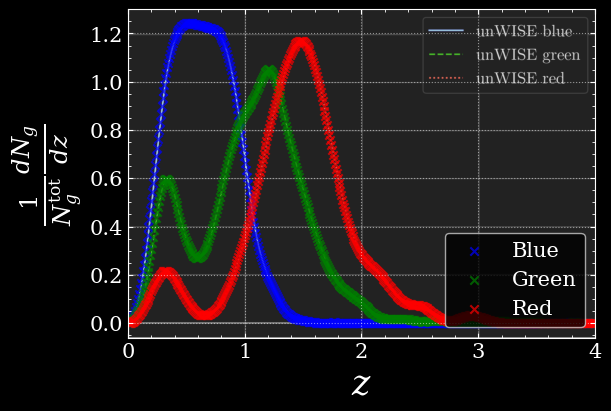

In [ ]:
importlib.reload(Plots); importlib.reload(TargetData)
fig, ax = Plots.Kusiak2022().Fig2()

for subsamp, color in zip(['Blue', 'Green', 'Red'], ['b', 'g', 'r']):
    K22 = TargetData.Kusiak2022({'sample':subsamp})
    K22.make_zdists()
    ax.scatter(K22.z, K22.dNdz_norm, c=color, marker='x', alpha=0.7, label=subsamp)

ax.legend(loc='lower right')
plt.show()

## Liu 2025

z1 paper ndens=81.9 1 / deg2, sum of n 82.01 1 / deg2, int of dndz 82.01 1 / (dex deg2)
z2 paper ndens=148.1 1 / deg2, sum of n 148.18 1 / deg2, int of dndz 148.18 1 / (dex deg2)
z3 paper ndens=162.4 1 / deg2, sum of n 162.52 1 / deg2, int of dndz 162.52 1 / (dex deg2)
z4 paper ndens=148.3 1 / deg2, sum of n 148.50 1 / deg2, int of dndz 148.50 1 / (dex deg2)


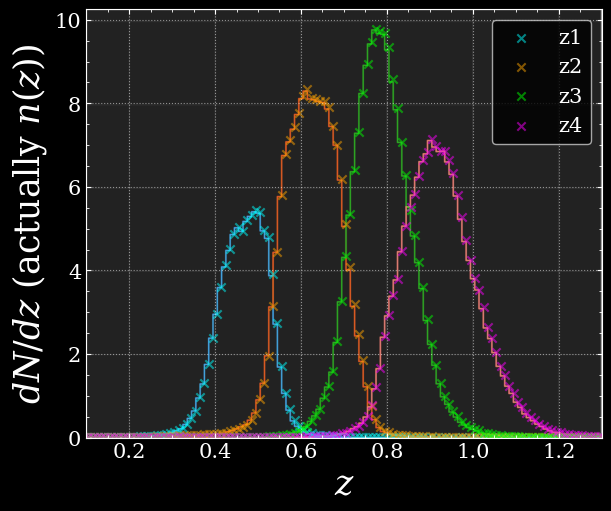

In [ ]:
importlib.reload(Plots); importlib.reload(TargetData)
fig, ax = Plots.Liu2025().Fig2()

for zbin, color in zip(['z1', 'z2', 'z3', 'z4'], ['cyan', 'orange', 'lime', 'magenta']):
    L25 = TargetData.Liu2025(zbin=zbin)
    L25.make_zdists()
    print(f'{L25.zbin} paper ndens={L25.nGal}, sum of n {np.sum(L25.n_z):.2f}, int of dndz {np.trapz(L25.dndz, L25.z):.2f}')
    ax.scatter(L25.z, L25.n_z, alpha=0.5, marker='x', c=color, label=f'{L25.zbin}')

ax.legend()
plt.show()

## Ried-Guachalla 2025

z_1 Ngal=195877 from paper, sum of N_z 195951, int of dNdz 179660
z_2 Ngal=235620 from paper, sum of N_z 297541, int of dNdz 271325
z_3 Ngal=235620 from paper, sum of N_z 235710, int of dNdz 210497
z_4 Ngal=96346 from paper, sum of N_z 96378, int of dNdz 93842


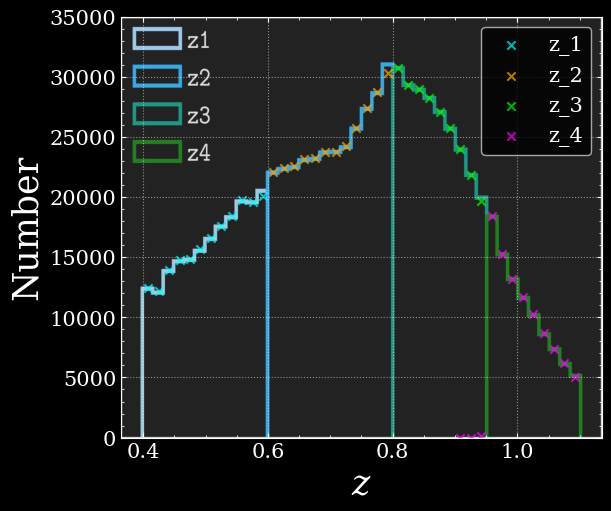

In [ ]:
importlib.reload(Plots); importlib.reload(TargetData)
fig, ax = Plots.RiedGuachalla2025().Fig2()

for bin, color in zip(['z_1', 'z_2', 'z_3', 'z_4'], ['cyan', 'orange', 'lime', 'magenta']):
    RG25 = TargetData.RiedGuachalla2025(bin=bin)
    RG25.make_zdists(dz=0.0167)
    print(f'{RG25.bin} Ngal={RG25.NGal} from paper, sum of N_z {RG25.N_z.sum():.0f}, int of dNdz {np.trapz(RG25.dNdz, RG25.z):.0f}')
    ax.scatter(RG25.z, RG25.N_z, alpha=0.7, marker='x', c=color, label=f'{RG25.bin}')

ax.legend()
plt.show()

mass_1 Ngal=244932, sum of N_logMs 244932, int of dNdlogMs 212246
mass_2 Ngal=320914, sum of N_logMs 320914, int of dNdlogMs 285314
mass_3 Ngal=194037, sum of N_logMs 194037, int of dNdlogMs 144324
mass_4 Ngal=53997, sum of N_logMs 53997, int of dNdlogMs 43972


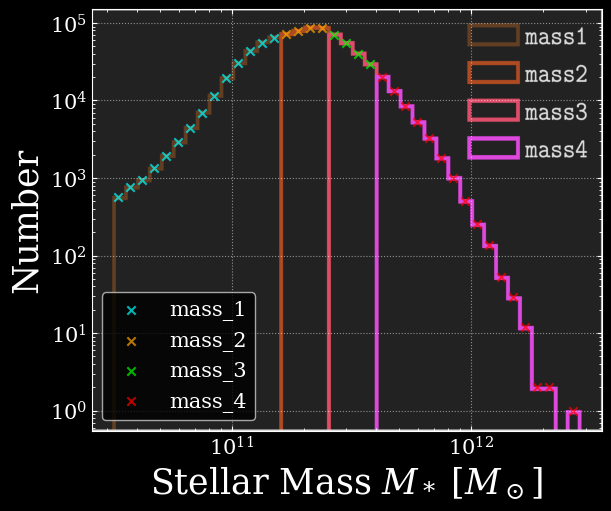

In [ ]:
importlib.reload(Plots); importlib.reload(TargetData)
fig, ax = Plots.RiedGuachalla2025().Fig3()

for bin, color in zip(['mass_1', 'mass_2', 'mass_3', 'mass_4'], ['cyan', 'orange', 'lime', 'red']):
    RG25 = TargetData.RiedGuachalla2025(bin=bin)
    RG25.make_Msdists(dlogMs=0.05)
    # logMs, N = RG25.get_dist('N_logMs', dlogMs=0.05)
    print(f'{RG25.bin} Ngal={RG25.NGal}, sum of N_logMs {RG25.N_logMs.sum():.0f}, int of dNdlogMs {np.trapz(RG25.N_logMs/RG25.dlogMs, RG25.logMs):.0f}')
    ax.scatter(10**RG25.logMs, RG25.N_logMs, alpha=0.7, marker='x', c=color, label=f'{RG25.bin}')

ax.legend(loc='lower left')
plt.show()

## Gao 2023

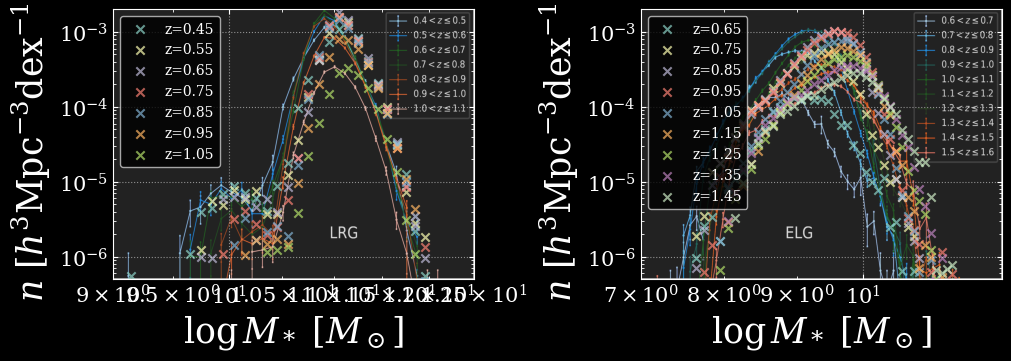

In [ ]:
importlib.reload(Plots); importlib.reload(TargetData)
fig, axs = Plots.Gao2023().Fig2()

G23= TargetData.Gao2023(sample='LRG')
G23.make_zMsdists()
for i, z in enumerate(G23.z):
    axs[0].scatter(G23.logMs, G23.n_logMs_z_h3[i], alpha=0.7, marker='x', label=f'z={z:.2f}')

G23 = TargetData.Gao2023(sample='ELG')
G23.make_zMsdists()
for i, z in enumerate(G23.z):
    axs[1].scatter(G23.logMs, G23.n_logMs_z_h3[i], alpha=0.7, marker='x', label=f'z={z:.2f}')

axs[0].legend(fontsize=10, loc='upper left'); axs[1].legend(fontsize=10, loc='upper left')
plt.show()

In [ ]:
G23= TargetData.Gao2023(sample='LRG')
G23.make_zMsdists()
mcut = (G23.logMs_df>=11.1) & (G23.logMs_df<=11.9)
zcut = (G23.z_df>=0.8) & (G23.z_df<=1.0)
N_z_logMs = G23.dNdzdlogMs_df*(G23.z_df[1]-G23.z_df[0])*(G23.logMs_df[1]-G23.logMs_df[0]) * u.dex**2
print(G23.z_df[zcut], G23.logMs_df[mcut])
N = 13906+4834+957+124
print(np.sum(N_z_logMs[:,mcut][zcut], axis=0).reshape(-1, 2).sum(axis=1))
print(f'{N:.3e}', f'{np.sum(N_z_logMs[:,mcut][zcut]):.3e}')

[0.85 0.95] [11.15 11.25 11.35 11.45 11.55 11.65 11.75 11.85]
[13820.64802317  4819.76390403   958.53731266   125.9293599 ]
1.982e+04 1.972e+04


In [ ]:
G23= TargetData.Gao2023(sample='LRG')
G23.make_zMsdists(dlogMs=0.001, dz=0.01)
mcut = (G23.logMs>=11.1) & (G23.logMs<=11.9)
zcut = (G23.z>=0.8) & (G23.z<=1.0)
N = 13906+4834+957+124
print(f'{N:.3e}', f'{np.sum(G23.N_z_logMs[:,mcut][zcut]):.3e}')
print(f'{np.trapz(G23.dNdz, G23.z*u.dex):.3e}', f'{np.sum(G23.N_z_logMs):.3e}')

G23= TargetData.Gao2023(sample='ELG')
G23.make_zMsdists(dlogMs=0.001, dz=0.01)
mcut = (G23.logMs>=8.5) & (G23.logMs<=10.5)
zcut = (G23.z>=0.8) & (G23.z<=1.0)
N=9481+29764+34155+6583
print(f'{N:.3e}', f'{np.sum(G23.N_z_logMs[:,mcut][zcut]):.3e}')
print(f'{np.trapz(G23.dNdz, G23.z*u.dex):.3e}', f'{np.sum(G23.N_z_logMs):.3e}')

# All

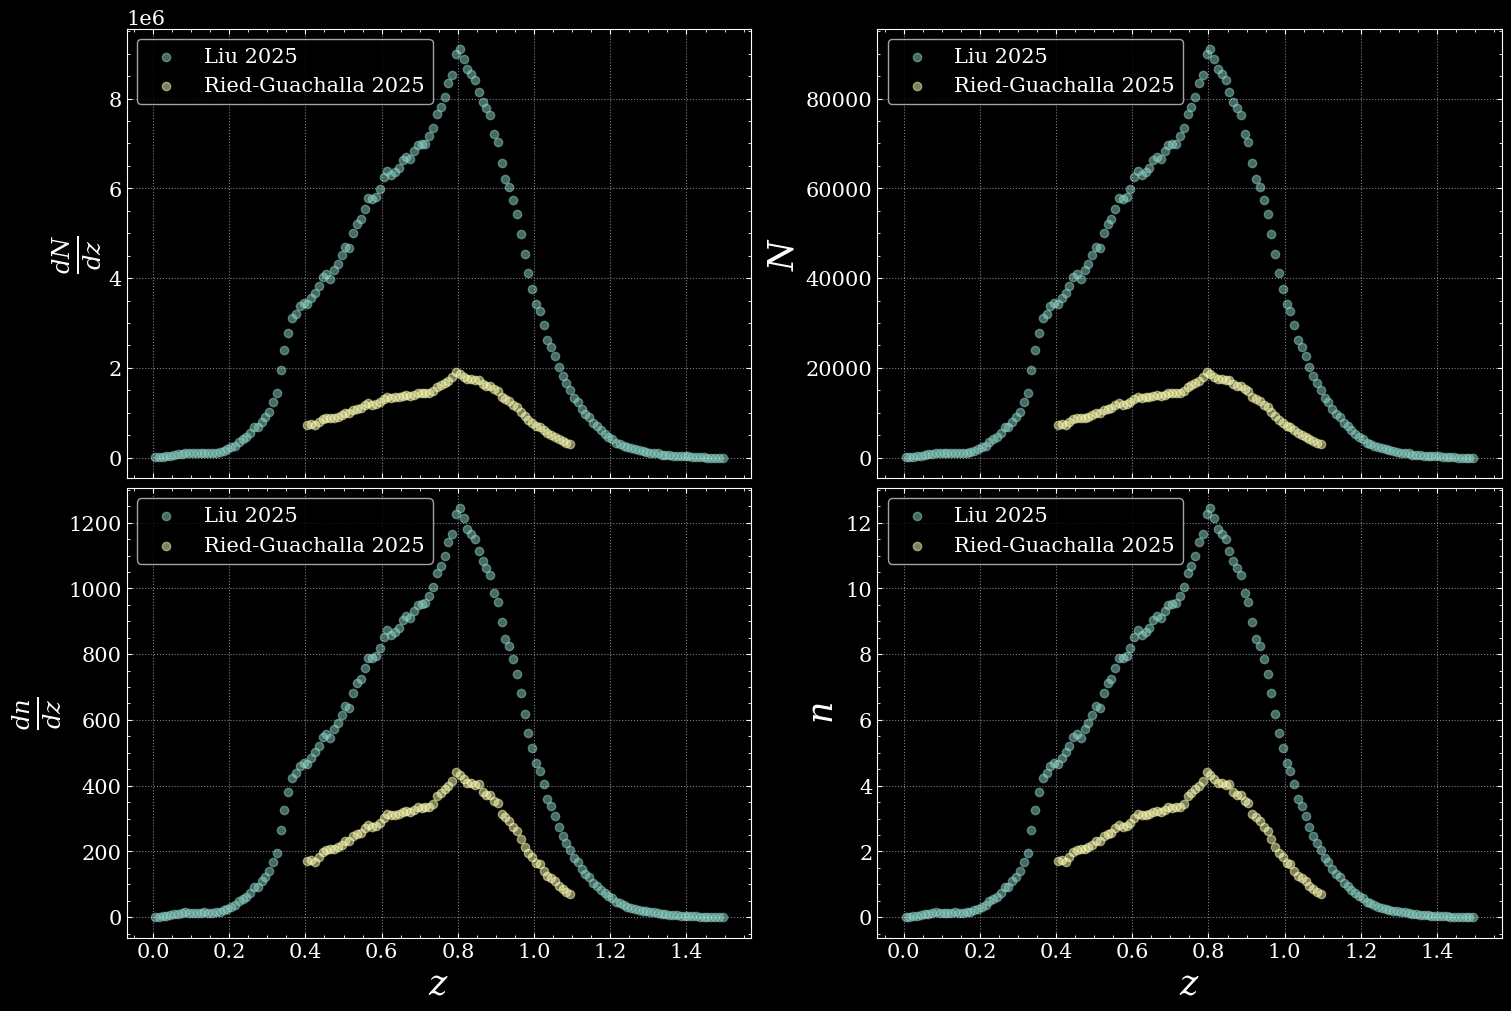

In [ ]:
importlib.reload(Studies); importlib.reload(TargetData)

fig, axs = plt.subplots(2, 2, figsize=(15, 10), layout='constrained', sharex='col')
axs=axs.flatten()

L25 = TargetData.Liu2025(zbin='all')
RG25 = TargetData.RiedGuachalla2025(bin='all')

for mod, name in zip([L25, RG25], ['Liu 2025', 'Ried-Guachalla 2025']):
    mod.make_zdists()
    axs[0].scatter(mod.z, mod.dNdz, alpha=0.5, label=name)
    axs[1].scatter(mod.z, mod.N_z, alpha=0.5, label=name)
    axs[2].scatter(mod.z, mod.dndz, alpha=0.5, label=name)
    axs[3].scatter(mod.z, mod.n_z, alpha=0.5, label=name)

axs[0].set(ylabel=r'$\frac{dN}{dz}$'); axs[0].legend()
axs[1].set(ylabel=r'$N$'); axs[1].legend()
axs[2].set(xlabel=r'$z$', ylabel=r'$\frac{dn}{dz}$'); axs[2].legend()
axs[3].set(xlabel=r'$z$', ylabel=r'$n$'); axs[3].legend()
plt.show()

# Unchecked

## White 2022

paper ndens: 83.0 1 / deg2, sum of n: 82.44 1 / deg2, 29635
paper ndens: 149.0 1 / deg2, sum of n: 147.13 1 / deg2, 52884
paper ndens: 162.0 1 / deg2, sum of n: 159.66 1 / deg2, 57383
paper ndens: 149.0 1 / deg2, sum of n: 146.79 1 / deg2, 52784


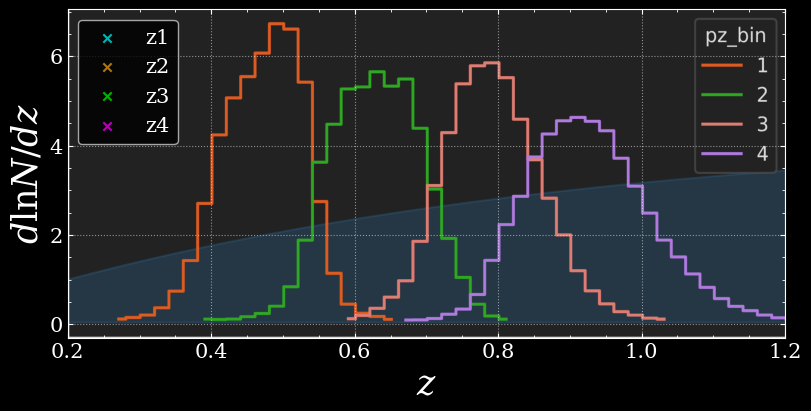

In [ ]:
importlib.reload(Plots); importlib.reload(TargetData)
fig, ax = Plots.White2022().Fig2()

for zbin, color in zip(['z1', 'z2', 'z3', 'z4'], ['cyan', 'orange', 'lime', 'magenta']):
    W22 = TargetData.White2022(zbin=zbin)
    W22.make_zdists()
    print(f'paper ndens: {W22.ndens}, sum of n: {np.sum(W22.n_z):.2f}, {np.trapz(W22.N_z, W22.z):.0f}')
    ax.scatter(W22.z, W22.dNdz, c=color, marker='x', alpha=0.7, label=zbin)

ax.legend(loc='upper left')
plt.show()

## Zhou 2023

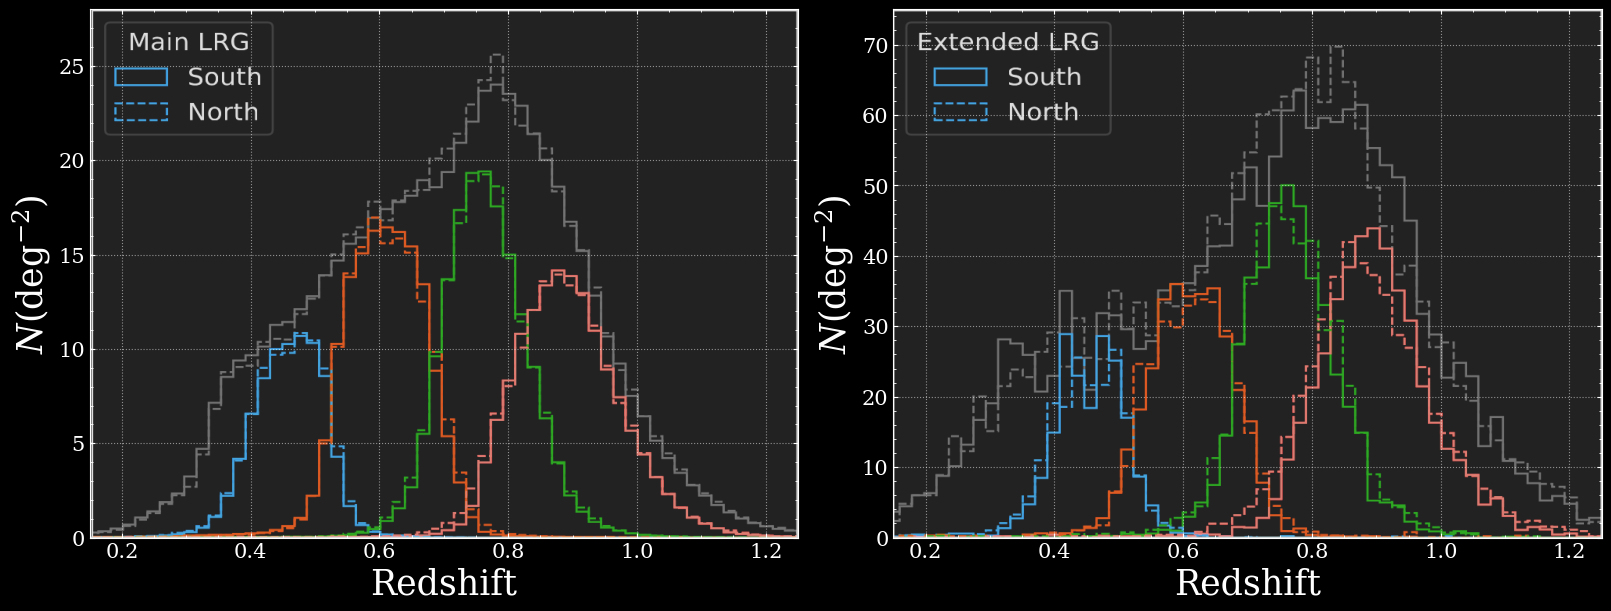

In [99]:
importlib.reload(Plots); importlib.reload(TargetData)
fig, ax = Plots.Zhou2023().Fig2()

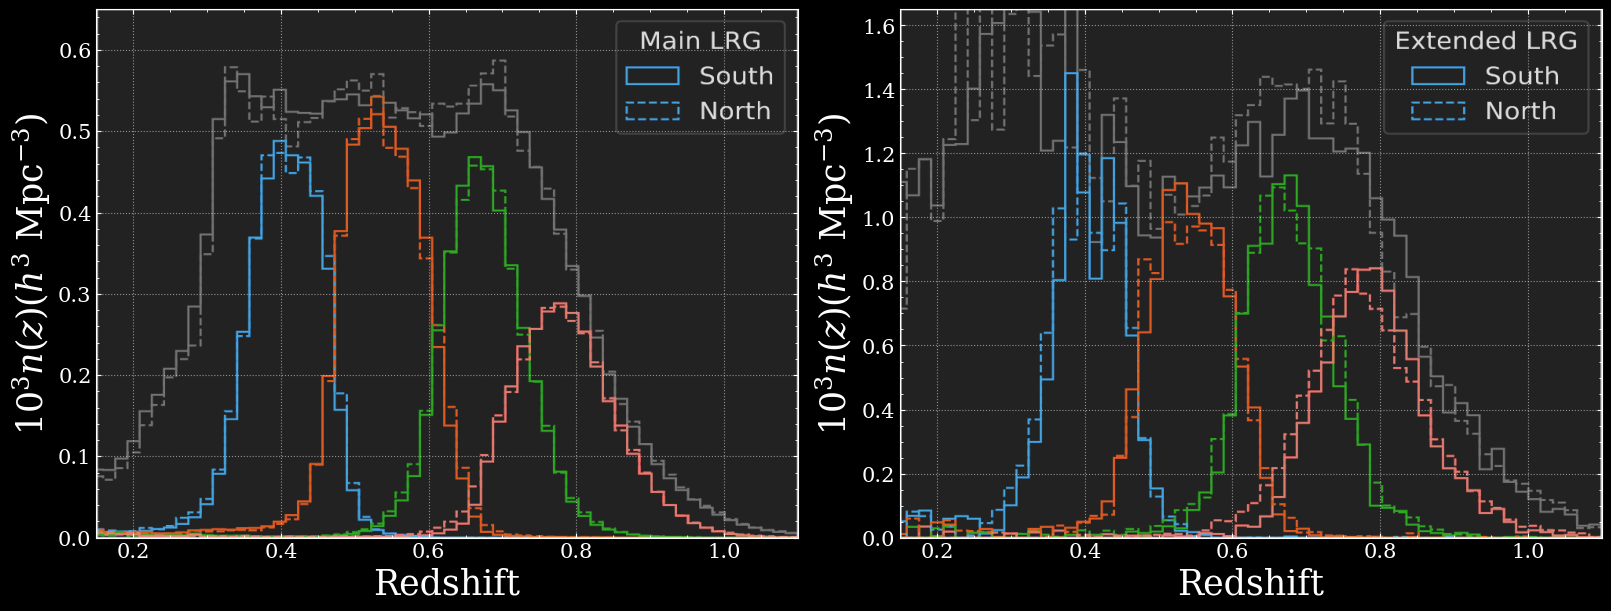

In [101]:
importlib.reload(Plots); importlib.reload(TargetData)
fig, ax = Plots.Zhou2023().Fig3()

## Moser 2021

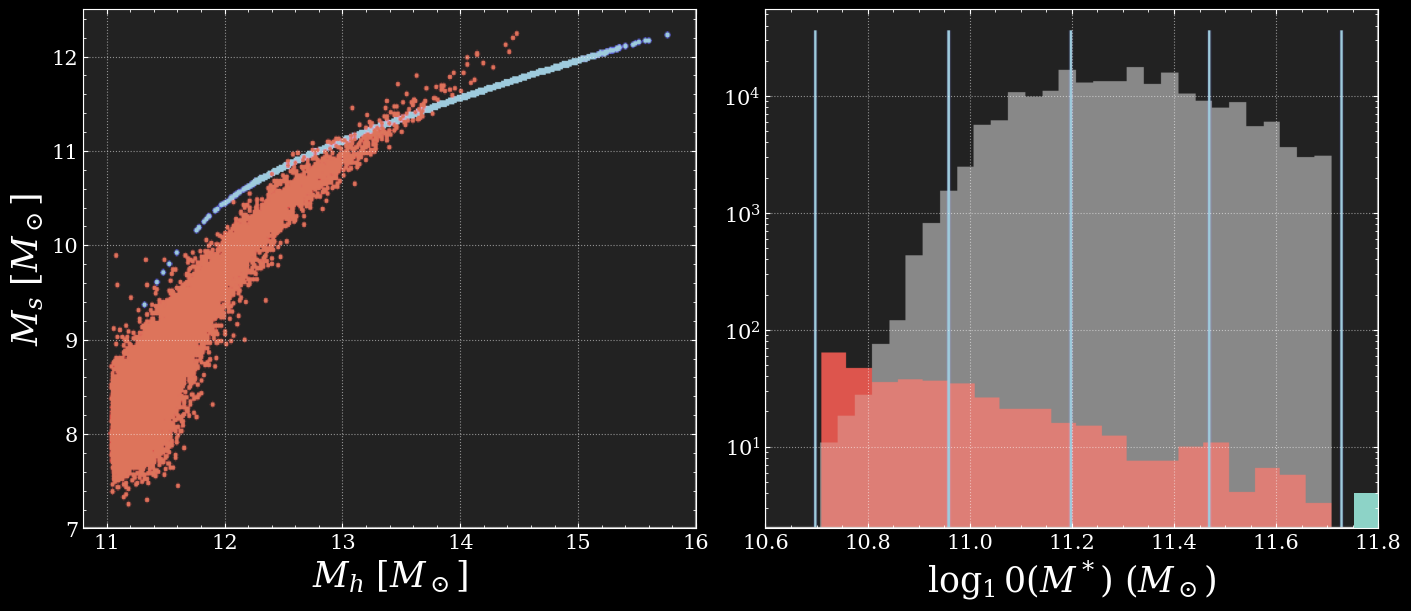

In [ ]:
importlib.reload(Plots); importlib.reload(TargetData)
fig, axs = Plots.Moser2021().Fig3()

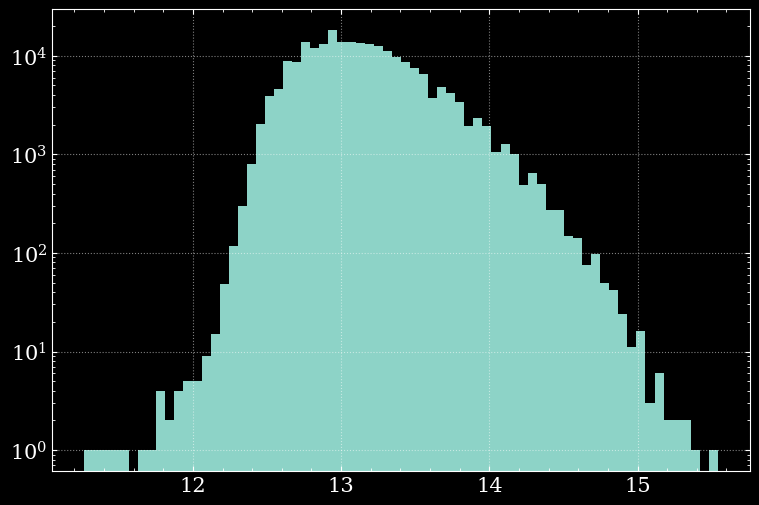

In [5]:
masses=np.loadtxt('/global/homes/c/cpopik/Data/Amodeo2021/mass_distrib.txt')
plt.hist(np.log10(masses), bins=70)
plt.yscale('log')

## Ried-Guachalla 2025

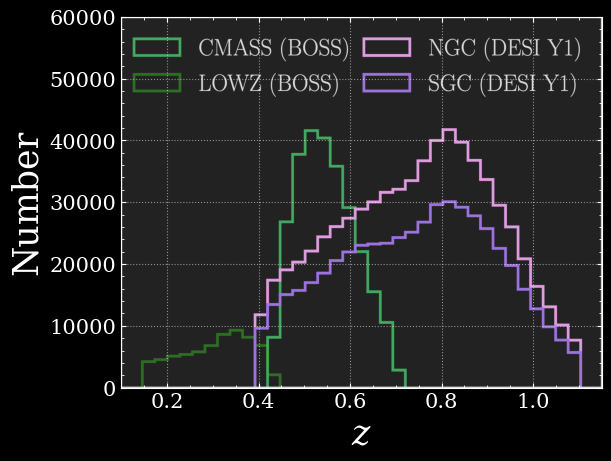

In [120]:
import Plots
importlib.reload(Plots)

fig, ax = Plots.RiedGuachalla2025().Fig20()

## Yuan 2023

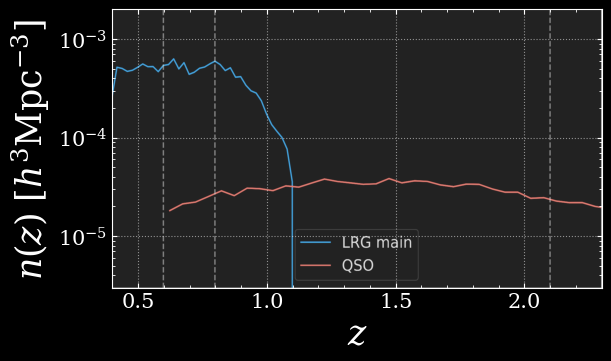

In [132]:
import Plots
importlib.reload(Plots)

fig, ax = Plots.Yuan2023().Fig1()

## Schaan 2021

In [ ]:
thing = np.loadtxt('/global/homes/c/cpopik/TargetData/Schaan2021/catalog.txt')
# 0:RA, 1:DEC, 2:z, 18:?, 20-:?

(10.5, 12.0)

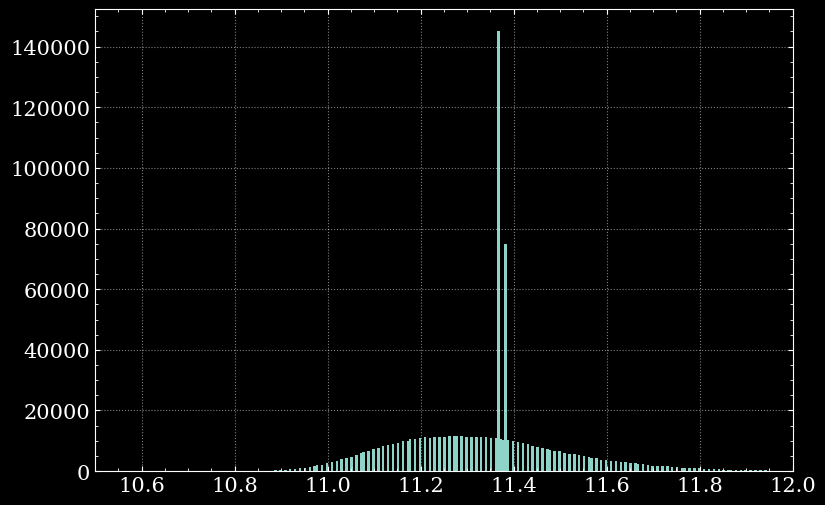

In [65]:
plt.hist(np.log10(thing[:,18]), bins=900)
plt.xlim(10.5, 12)

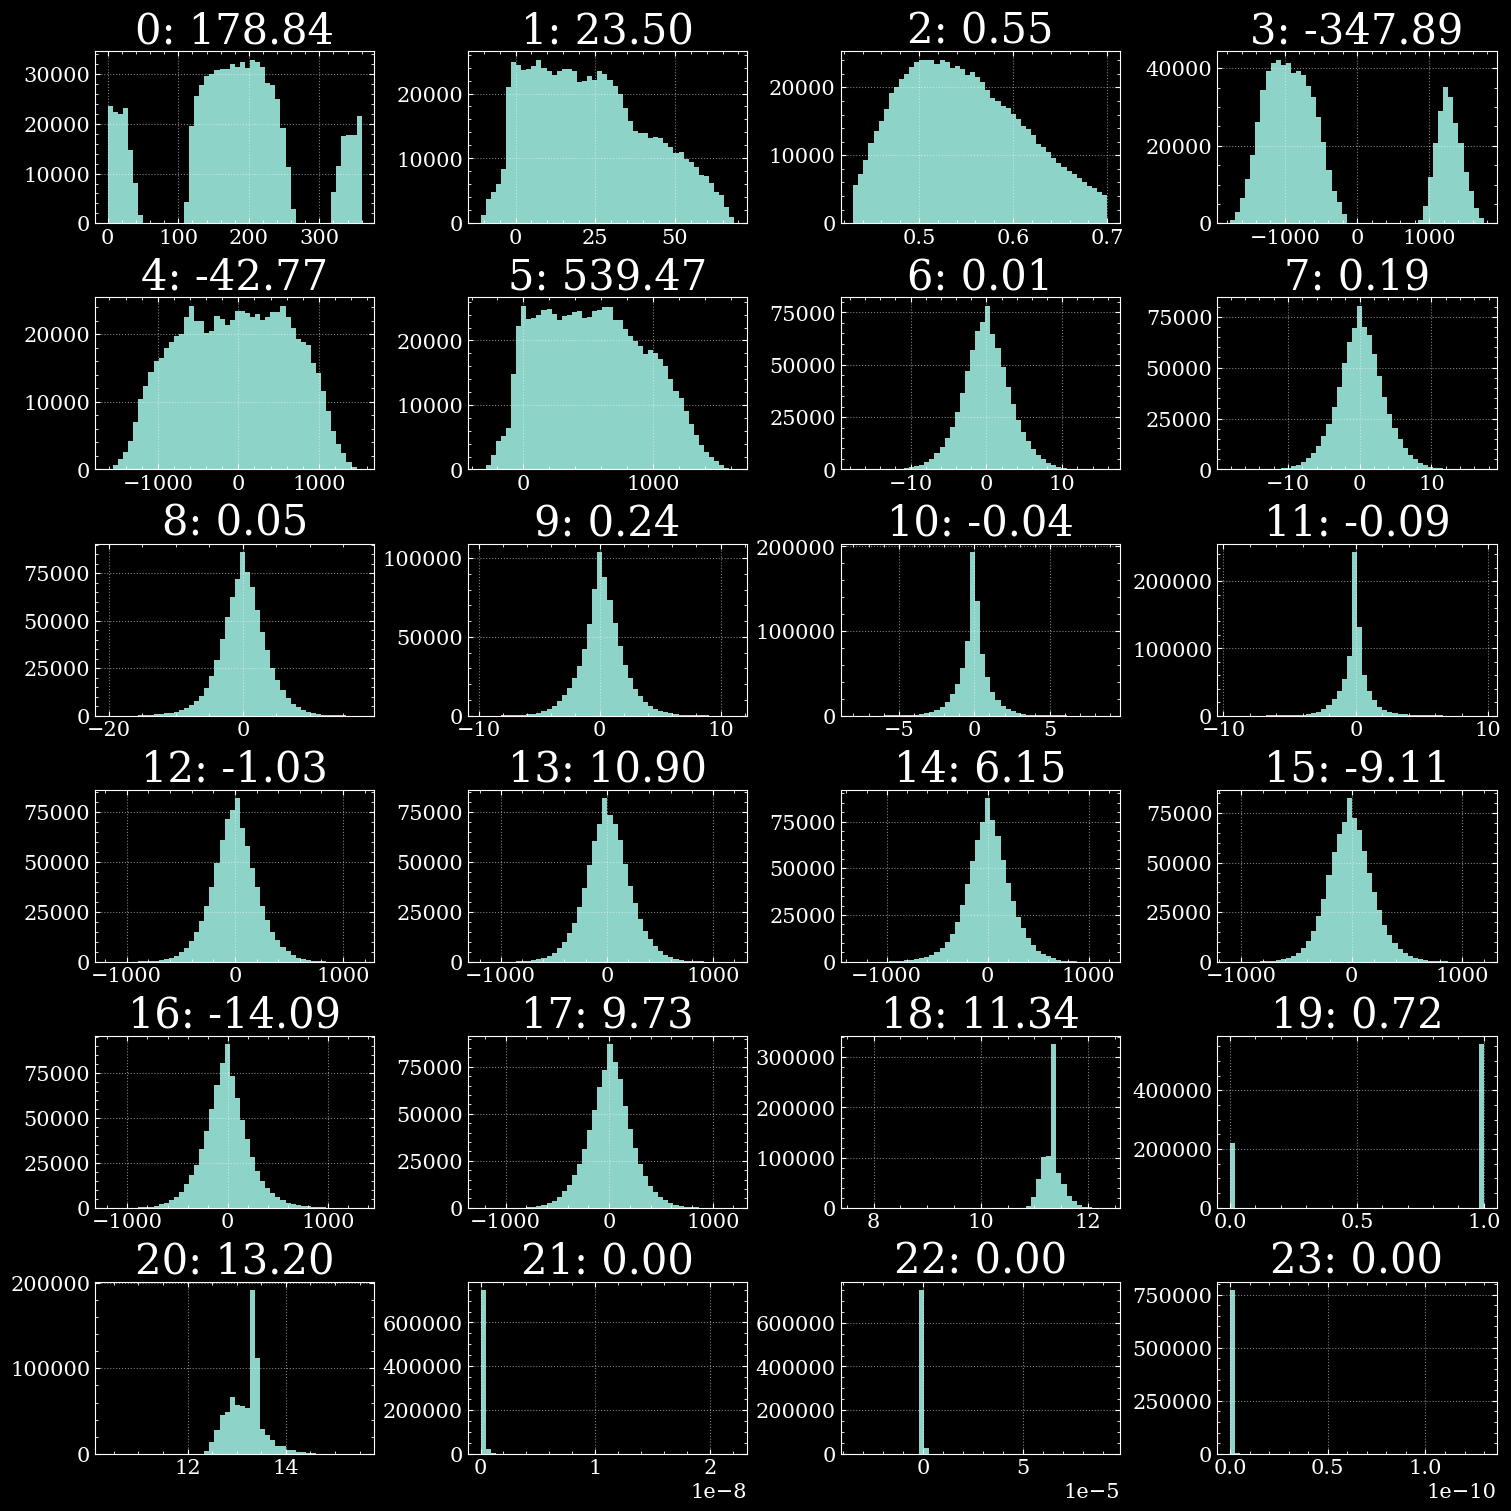

In [49]:
fig, axs = plt.subplots(6, 4, figsize=(15, 15), layout='constrained')
axs=axs.flatten()
for i, ax in zip(range(24), axs):
    if i in [18, 20]:
        ax.hist(np.log10(thing[:,i]), bins=50)
        ax.set_title(f'{i}: {np.mean(np.log10(thing[:,i])):.2f}')
    else: 
        ax.hist(thing[:,i], bins=50)
        ax.set_title(f'{i}: {np.mean(thing[:,i]):.2f}')

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


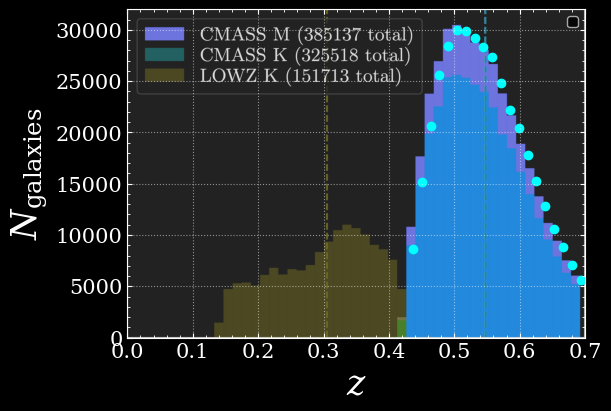

In [ ]:
fig, ax = Plots.Schaan2021().Fig2()

import TargetData
importlib.reload(TargetData)

y, x = np.histogram(thing[:,2], bins=20)
ax.scatter((x[1:]+x[:-1])/2, y/2, c='cyan')

# dz=0.7/49

# CMASSDR10 = TargetData.SDSSBOSS({'galaxy':'CMASS', 'DR':'DR10', 'group':'portsmouth', 'template':'passive', 'IMF':'krou'})
# dNdz, z = CMASSDR10.get_dNdz(dz)
# ax.scatter(z, dNdz*CMASSDR10.dz, label=f'CMASS K {np.trapz(dNdz, z*u.dex)}')

# LOWZDR10 = TargetData.SDSSBOSS({'galaxy':'LOWZ', 'DR':'DR10', 'group':'portsmouth', 'template':'passive', 'IMF':'krou'})
# dNdz, z = LOWZDR10.get_dNdz(dz)
# ax.scatter(z, dNdz*dz, label=f'LOWZ K {np.trapz(dNdz, z*u.dex)}')

# CMASSDR12 = TargetData.SDSSBOSS({'galaxy':'CMASS', 'DR':'DR12', 'group':'portsmouth', 'template':'passive', 'IMF':'krou'})
# dNdz, z = CMASSDR12.get_dNdz(dz)
# ax.scatter(z, dNdz*dz, label=f'CMASS M {np.trapz(dNdz, z*u.dex)}')

ax.legend(fontsize=10)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


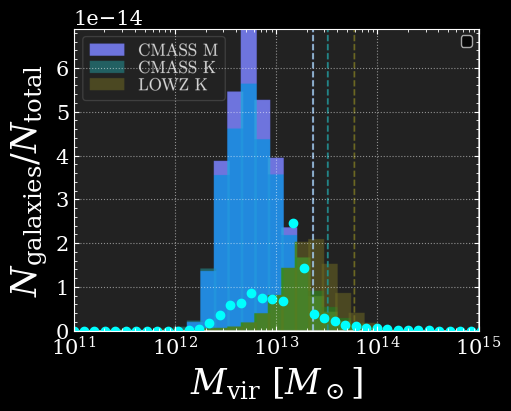

In [120]:
fig, ax = Plots.Schaan2021().Fig3()

y, x = np.histogram(np.log10(thing[:,20]), bins=50)
ax.scatter(10**((x[1:]+x[:-1])/2)*0.7, y/thing.shape[0]/1e13, c='cyan')

ax.legend(fontsize=10)
plt.show()

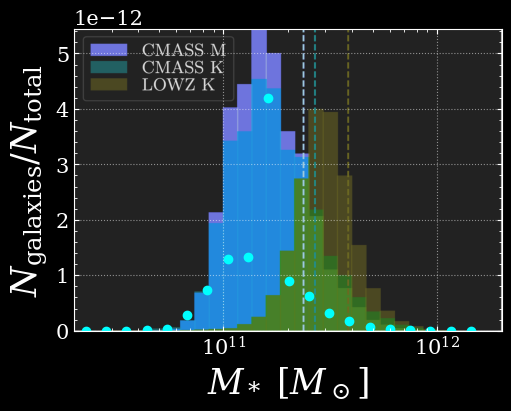

In [ ]:
import Plots
importlib.reload(Plots)

fig, ax = Plots.Schaan2021().Fig31()

y, x = np.histogram(np.log10(thing[:,18]), bins=50)
ax.scatter(10**((x[1:]+x[:-1])/2)*0.7, y/thing.shape[0]/1e11, c='cyan')
